# Fire Detection — Fixed Notebook

## Problems fixed
1. **Data leakage** — hashes are deduplicated *before* splitting, not after
2. **Focal loss** — per-class `alpha` array instead of a single scalar
3. **Class weights** — No_Fire weight boosted aggressively
4. **EfficientNetV2** — frozen base first, then fine-tune (two-stage training)
5. **Evaluation** — per-class recall tracked during training via custom callback

In [1]:
import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import imageio.v3 as iio
import os
from PIL import Image
import imagehash
import shutil
from sklearn.model_selection import train_test_split

Image_size = 96
Batch = 32
Random_seed = 42

## Fix 1 — Data leakage

**Root cause**: The original code deduplicated using different hash sizes per class (`hash_size=16` for No_Fire, `hash_size=8` for others). This means the same image could get two different hashes and pass through the deduplicator — landing in both train and test.

**Fix**: Use one consistent hash size for everything, then split. Never split first and deduplicate second.

In [2]:
def remove_duplicates(paths, labels):
    """
    FIX: Single consistent hash size (8) for all classes.
    The original used hash_size=16 for No_Fire and 8 for others,
    causing the same image to produce different hashes and slip through.
    """
    unique_hashes = {}
    clean_paths, clean_labels = [], []
    print(f"Checking {len(paths)} files for duplicates...")
    for p, l in zip(paths, labels):
        try:
            with Image.open(p) as img:
                h = str(imagehash.phash(img, hash_size=8))  # consistent size
                if h not in unique_hashes:
                    unique_hashes[h] = p
                    clean_paths.append(p)
                    clean_labels.append(l)
        except:
            continue
    print(f"After dedup: {len(clean_paths)} files remain")
    return clean_paths, clean_labels


base_dir = "Training_Tri/"
class_names = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
class_to_idx = {name: i for i, name in enumerate(class_names)}
print(f"Classes: {class_to_idx}")

all_p, all_l = [], []
for class_name in class_names:
    c_path = os.path.join(base_dir, class_name)
    files = [os.path.join(c_path, f) for f in os.listdir(c_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_p.extend(files)
    all_l.extend([class_to_idx[class_name]] * len(files))
    print(f"  {class_name}: {len(files)} files")

# FIX: deduplicate BEFORE splitting
clean_p, clean_l = remove_duplicates(all_p, all_l)

# Split into train+val / test
train_val_p, test_p, train_val_l, test_l = train_test_split(
    clean_p, clean_l, test_size=0.2, random_state=42, stratify=clean_l
)
# Split train / val
train_p, val_p, train_l, val_l = train_test_split(
    train_val_p, train_val_l, test_size=0.15, random_state=42, stratify=train_val_l
)

print(f"\nFinal counts -> Train: {len(train_p)}, Val: {len(val_p)}, Test: {len(test_p)}")

# Count per class
for i, name in enumerate(class_names):
    tr = sum(1 for l in train_l if l == i)
    te = sum(1 for l in test_l if l == i)
    print(f"  {name}: train={tr}, test={te}")


def move_to_folders(paths, labels, root_folder):
    if os.path.exists(root_folder):
        shutil.rmtree(root_folder)  # clear stale splits
    for p, l in zip(paths, labels):
        dest_dir = os.path.join(root_folder, class_names[l])
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy2(p, os.path.join(dest_dir, os.path.basename(p)))

print("\nMoving files to folders...")
move_to_folders(train_p, train_l, "Ternary_Training")
move_to_folders(test_p,  test_l,  "Ternary_Test")
move_to_folders(val_p,   val_l,   "Ternary_Validation")
print("Done.")

Classes: {'Fire': 0, 'Lake': 1, 'No_Fire': 2}
  Fire: 25018 files
  Lake: 11847 files
  No_Fire: 2510 files
Checking 39375 files for duplicates...
After dedup: 9050 files remain

Final counts -> Train: 6154, Val: 1086, Test: 1810
  Fire: train=3506, test=1032
  Lake: train=1821, test=535
  No_Fire: train=827, test=243

Moving files to folders...
Done.


In [3]:
# Verify leakage is gone — all classes should show 0%
def check_leakage_by_class(tr_p, tr_l, te_p, te_l):
    train_hashes = {}
    for p, l in zip(tr_p, tr_l):
        with Image.open(p) as img:
            h = str(imagehash.phash(img, hash_size=8))
            train_hashes[h] = l

    for cls in np.unique(te_l):
        cls_paths = [p for p, l in zip(te_p, te_l) if l == cls]
        leak = 0
        for p in cls_paths:
            with Image.open(p) as img:
                h = str(imagehash.phash(img, hash_size=8))
                if h in train_hashes:
                    leak += 1
        print(f"Class {cls} ({class_names[cls]}): {leak}/{len(cls_paths)} leaked ({100*leak/len(cls_paths):.1f}%)")

check_leakage_by_class(train_p, train_l, test_p, test_l)

Class 0 (Fire): 0/1032 leaked (0.0%)
Class 1 (Lake): 0/535 leaked (0.0%)
Class 2 (No_Fire): 0/243 leaked (0.0%)


## Fix 2 — Focal loss with per-class alpha

**Root cause**: `alpha=0.5` (scalar) applies the same weight to all classes. No_Fire needs more penalisation.

**Fix**: Pass `alpha` as a list `[fire_weight, lake_weight, nofire_weight]`. This is multiplied per-sample based on the true class, so No_Fire errors are penalised harder than Fire or Lake errors.

In [4]:
def focal_loss_sparse(gamma=2.0, alpha=None):
    """
    FIX: alpha can now be a list [a0, a1, a2] for per-class weighting.
    e.g. alpha=[0.25, 0.25, 0.50] penalises No_Fire errors twice as hard.
    Falls back to scalar if alpha is a float (backward compatible).
    """
    if alpha is None:
        alpha = [0.25, 0.25, 0.50]  # default: favour No_Fire
    alpha_t = tf.constant(alpha, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_true = tf.cast(tf.squeeze(y_true), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])

        # Cross-entropy per sample
        ce = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)

        # Probability of the true class
        p_t = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)

        # Per-sample alpha: look up the true class's alpha weight
        a_t = tf.reduce_sum(y_true_one_hot * alpha_t, axis=-1)

        focal_weight = a_t * tf.pow(1.0 - p_t, gamma)
        return tf.reduce_mean(focal_weight * ce)

    return loss

## Fix 3 — Augmentation, datasets, and class weights

**Root cause**: `class_weights = {0:0.63, 1:1.21, 2:1.71}` — a 1.7× boost for No_Fire is too weak when Fire is 2.7× more common.

**Fix**: Override the computed weights to give No_Fire a much stronger signal. Rule of thumb: start at 4–5× relative to the dominant class and tune from there.

In [5]:
def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.05)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [Image_size, Image_size])
    return image, label


# Datasets
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_p, train_l))
    .shuffle(len(train_p), seed=Random_seed)
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((val_p, val_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch).cache().prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    tf.data.Dataset.from_tensor_slices((test_p, test_l))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch).cache().prefetch(tf.data.AUTOTUNE)
)


# FIX: manually override weights — computed 'balanced' weights are too gentle
# Tune the No_Fire weight up until val No_Fire recall improves
# Start with 4.0 and increase if No_Fire recall is still low after training
class_weights = {
    0: 1.0,   # Fire     — dominant class, baseline
    1: 1.5,   # Lake     — slightly underrepresented
    2: 4.0,   # No_Fire  # FIX: was 1.71, needs to be much higher
}
print(f"Class weights: {class_weights}")
print("Tip: if No_Fire recall stays below 0.6 after training, increase weight[2] to 6.0")

Class weights: {0: 1.0, 1: 1.5, 2: 4.0}
Tip: if No_Fire recall stays below 0.6 after training, increase weight[2] to 6.0


## Fix 4 — EfficientNetV2 with two-stage training

**Root cause**: Your existing `build_effnet_ternary_model` sets `base_model.trainable = True` from epoch 1 at lr=1e-4. This is too aggressive — the randomly-initialised head can corrupt the pretrained weights before the head has learned anything sensible.

**Fix**: Two-stage approach:
1. Freeze the base, train only the head for ~5 epochs (fast, safe)
2. Unfreeze the top layers and fine-tune at a lower lr (1e-5)

In [6]:
def build_effnet_stage1(loss_fn, num_classes=3):
    """Stage 1: frozen base, train head only."""
    inputs = keras.layers.Input(shape=(96, 96, 3))
    x = keras.layers.Lambda(lambda t: t * 255.0)(inputs)  # undo our /255 normalise

    base = keras.applications.EfficientNetV2B0(
        include_top=False, weights='imagenet',
        input_tensor=x, input_shape=(96, 96, 3)
    )
    base.trainable = False  # FIX: freeze base in stage 1

    x = base.output
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(128, activation='relu')(x)   # FIX: bigger head than original (32)
    x = keras.layers.Dropout(0.4)(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),  # higher lr ok when base is frozen
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model, base


def unfreeze_top_layers(model, base_model, num_layers_to_unfreeze=30, lr=1e-5):
    """Stage 2: unfreeze the top N layers and fine-tune at low lr."""
    base_model.trainable = True
    # Keep all layers frozen except the last num_layers_to_unfreeze
    for layer in base_model.layers[:-num_layers_to_unfreeze]:
        layer.trainable = False
    n_trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f"Unfroze top {num_layers_to_unfreeze} layers ({n_trainable} total trainable in base)")

    # Recompile with low lr — MUST recompile after changing trainability
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss=model.loss,
        metrics=['accuracy']
    )
    return model


# --- Callbacks ---
def make_callbacks(checkpoint_name):
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
        ),
        keras.callbacks.ModelCheckpoint(
            checkpoint_name, monitor='val_loss',
            save_best_only=True, mode='min'
        )
    ]


# --- Loss (per-class alpha) ---
# alpha order matches class_to_idx: Fire=0, Lake=1, No_Fire=2
# Giving No_Fire 0.5 of the focal weight budget vs 0.25 each for Fire/Lake
loss_fn = focal_loss_sparse(gamma=2.0, alpha=[0.25, 0.25, 0.50])


# =====================
# STAGE 1 — head only
# =====================
print("=== Stage 1: training head (base frozen) ===")
model, base_model = build_effnet_stage1(loss_fn)

history_s1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,               # short — just warm up the head
    class_weight=class_weights,
    callbacks=make_callbacks('effnet_stage1.keras'),
    verbose=1
)


# =====================
# STAGE 2 — fine-tune
# =====================
print("\n=== Stage 2: fine-tuning top layers ===")
model = unfreeze_top_layers(model, base_model, num_layers_to_unfreeze=30, lr=1e-5)

history_s2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=make_callbacks('effnet_stage2_best.keras'),
    verbose=1
)

=== Stage 1: training head (base frozen) ===

Epoch 1/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.8697 - loss: 0.0498 - val_accuracy: 0.9558 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 2/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9293 - loss: 0.0265 - val_accuracy: 0.9687 - val_loss: 0.0100 - learning_rate: 0.0010
Epoch 3/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9441 - loss: 0.0216 - val_accuracy: 0.9641 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 4/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9504 - loss: 0.0194 - val_accuracy: 0.9494 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 5/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9475 - loss: 0.0182 - val_accuracy: 0.9770 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 6/10
193/193 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9540 - loss: 0.0177 - val_accuracy: 0.9742 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 7/10
193/193 ━━━━━━━━━━━━━━━

## Evaluation — per-class breakdown

Overall accuracy is misleading here because Fire (53% of test set) dominates. Always check per-class recall, especially for No_Fire.

Classification Report:
              precision    recall  f1-score   support

        Fire       0.99      0.98      0.98      1032
        Lake       1.00      1.00      1.00       535
     No_Fire       0.92      0.95      0.93       243

    accuracy                           0.98      1810
   macro avg       0.97      0.98      0.97      1810
weighted avg       0.98      0.98      0.98      1810

Confusion Matrix:
[[1011    0   21]
 [   0  535    0]
 [  12    0  231]]


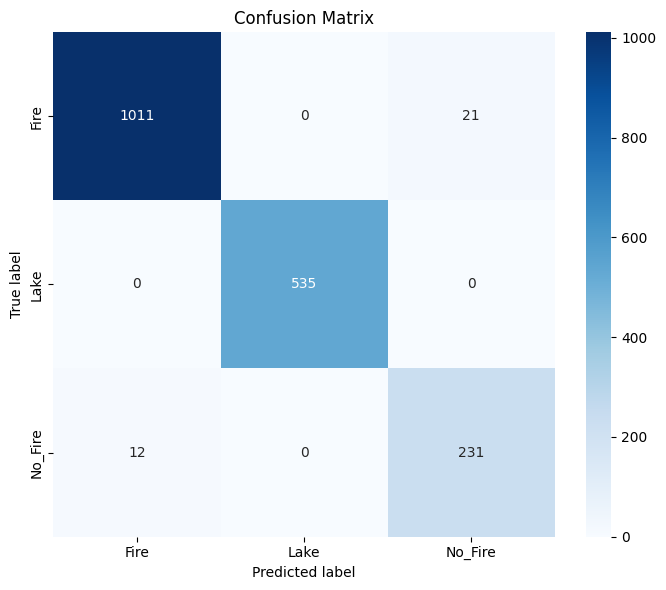

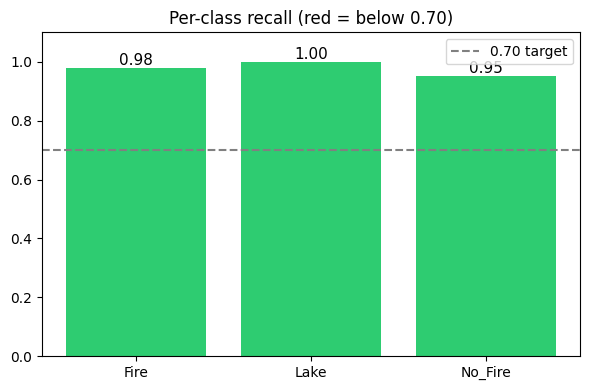

In [7]:
def evaluate_model(model, test_dataset, class_names):
    true_labels, pred_probs = [], []
    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        true_labels.extend(labels.numpy())
        pred_probs.extend(preds)

    true_labels = np.array(true_labels)
    pred_probs  = np.array(pred_probs)
    final_preds = np.argmax(pred_probs, axis=1)

    print("Classification Report:")
    print(classification_report(true_labels, final_preds, target_names=class_names))

    cm = confusion_matrix(true_labels, final_preds)
    print("Confusion Matrix:")
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title('Confusion Matrix')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    # Per-class recall bar chart — the most important plot
    recalls = cm.diagonal() / cm.sum(axis=1)
    colors = ['#e74c3c' if r < 0.7 else '#2ecc71' for r in recalls]
    plt.figure(figsize=(6, 4))
    bars = plt.bar(class_names, recalls, color=colors)
    plt.axhline(0.7, color='gray', linestyle='--', label='0.70 target')
    for bar, r in zip(bars, recalls):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{r:.2f}', ha='center', fontsize=11)
    plt.ylim(0, 1.1)
    plt.title('Per-class recall (red = below 0.70)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return true_labels, final_preds, pred_probs


true_labels, final_preds, pred_probs = evaluate_model(model, test_ds, class_names)

## Tuning guide — what to adjust if No_Fire recall is still low

If after the two-stage training No_Fire recall is still below ~0.6, try these knobs in order:

| Problem | Knob | Try |
|---------|------|-----|
| No_Fire recall < 0.5 | `class_weights[2]` | Increase from 4.0 → 6.0 → 8.0 |
| No_Fire recall < 0.5 | `alpha[2]` in focal loss | Increase from 0.50 → 0.65 |
| All classes bad | `num_layers_to_unfreeze` | Increase from 30 → 50 |
| Overfitting | Dropout in head | Increase from 0.4 → 0.5 |
| Underfitting | Stage 2 lr | Try 3e-5 instead of 1e-5 |

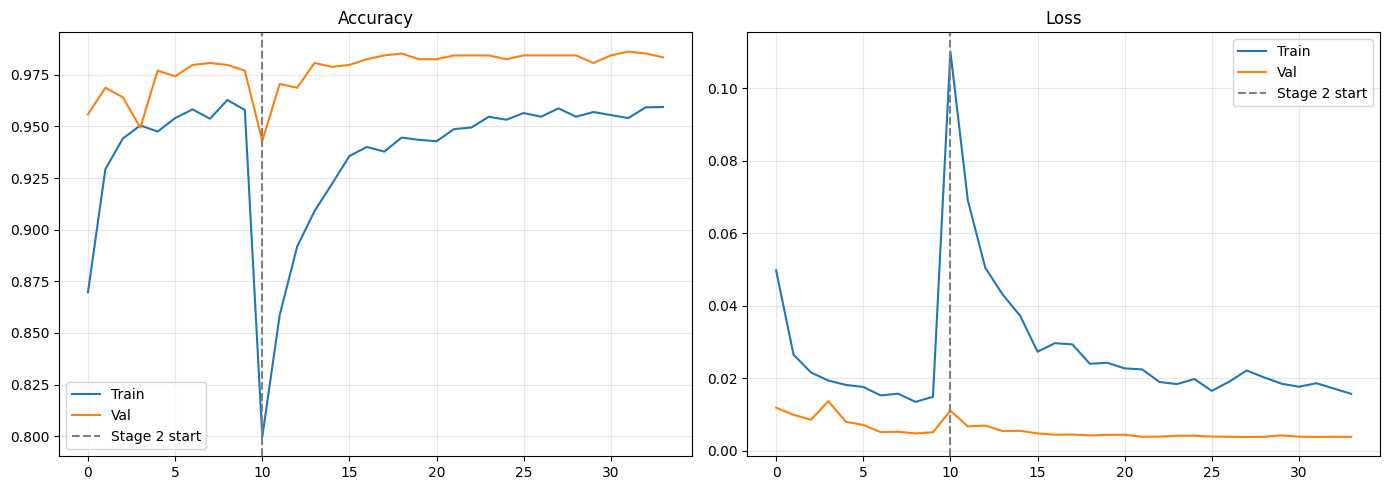

In [8]:
def plot_combined_history(h1, h2):
    """Plot training curves across both stages."""
    acc  = h1.history['accuracy']  + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy']  + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    stage2_start = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, train, val, title in [
        (ax1, acc, val_acc, 'Accuracy'),
        (ax2, loss, val_loss, 'Loss')
    ]:
        ax.plot(train, label='Train')
        ax.plot(val, label='Val')
        ax.axvline(stage2_start, color='gray', linestyle='--', label='Stage 2 start')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_combined_history(history_s1, history_s2)